## MLP for Classification

In [21]:
from sklearn.datasets import fetch_openml

fashion_mnist = fetch_openml(name='Fashion-MNIST', as_frame=False)
targets = fashion_mnist.target.astype(int)

X_train, y_train = fashion_mnist.data[:60_000], targets[:60_000]
X_test, y_test = fashion_mnist.data[60_000:], targets[60_000:]


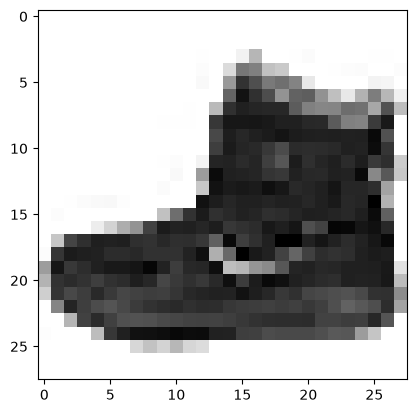

In [22]:
import matplotlib.pyplot as plt

X_sample = X_train[0].reshape(28, 28) # first image in the training set
plt.imshow(X_sample, cmap='binary')
plt.show()

In [23]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [24]:
y_train[0]

np.int64(9)

In [25]:
class_names[y_train[0]]

'Ankle boot'

In [26]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

mlp_clf = MLPClassifier(hidden_layer_sizes=[300,100], verbose=True, early_stopping=True, random_state=42)
pipeline = make_pipeline(MinMaxScaler(), mlp_clf)

In [27]:
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_test, y_test)

Iteration 1, loss = 0.55394420
Validation score: 0.854833
Iteration 2, loss = 0.39017365
Validation score: 0.867500
Iteration 3, loss = 0.34572472
Validation score: 0.877500
Iteration 4, loss = 0.31541926
Validation score: 0.881167
Iteration 5, loss = 0.29351007
Validation score: 0.887167
Iteration 6, loss = 0.28459028
Validation score: 0.889167
Iteration 7, loss = 0.26775210
Validation score: 0.885500
Iteration 8, loss = 0.25610516
Validation score: 0.886667
Iteration 9, loss = 0.24488907
Validation score: 0.893167
Iteration 10, loss = 0.23915583
Validation score: 0.888500
Iteration 11, loss = 0.22290961
Validation score: 0.897167
Iteration 12, loss = 0.21925185
Validation score: 0.889667
Iteration 13, loss = 0.21249406
Validation score: 0.892167
Iteration 14, loss = 0.20374069
Validation score: 0.891333
Iteration 15, loss = 0.19557455
Validation score: 0.893833
Iteration 16, loss = 0.19099949
Validation score: 0.893667
Iteration 17, loss = 0.18445775
Validation score: 0.890333
Iterat

In [28]:
accuracy

0.8929

2 hidden layers, w/ 300 and 100 neurons 

used MinMaxScaler to scale pixel values to 0-1 instead of 0-255
- features in this range work better with mlp classifier

In [32]:
X_new = X_test[:15]
mlp_clf.predict(X_new)

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 5, 3, 4])

In [ ]:
y_proba = mlp_clf.predict_proba(X_new)
y_proba[12] # 100% confident in its wrong anwser 12 should be 7 not 5
# model is actually very overconfident

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [33]:
mlp_clf.predict_proba(X_test)

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 10))